# Fraud Detection: False-Decline Reduction Model For Payment Authorizations
## Business Problem
Card payment networks face a core tension: fraud makes up under 0.1% of transactions by volume, yet costs the industry hundreds of billions annually. Rule-based systems that chase every fraud case tend to over-decline legitimate transactions instead — and industry research shows false declines cost merchants several times more than the fraud they're meant to prevent.

**Goal:** build a classifier that detects fraud in near real-time, optimized not for accuracy alone, but for minimizing total business cost — balancing missed fraud against wrongful declines.

**Approach:** engineered behavioral features (card-specific spending deviation, cyclical time encoding), trained XGBoost with imbalance handling, benchmarked against a Logistic Regression baseline, derived a cost-optimized decision threshold, and deployed as a live three-tier decisioning app (Approve / Review / Decline) using Streamlit.

**Result:** the validation-selected threshold of 0.52 caught **87.1% of fraud** on the untouched test set while reducing total estimated business cost by **5.1%** versus the default 0.5 threshold.

In [1]:
# import Libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# Load Dataset
df = pd.read_csv("card_transactions_2023_1.csv")

print("Shape:", df.shape)

Shape: (200000, 26)


In [ ]:
df.head()

In [4]:
df.dtypes

ssn            object
cc_num          int64
first          object
last           object
gender         object
street         object
city           object
state          object
zip             int64
lat           float64
long          float64
city_pop        int64
job            object
dob            object
acct_num        int64
profile        object
trans_num      object
trans_date     object
trans_time     object
unix_time     float64
category       object
amt           float64
is_fraud      float64
merchant       object
merch_lat     float64
merch_long    float64
dtype: object

In [5]:
# Step 3: Dataset Summary

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200000 entries, 0 to 199999
Data columns (total 26 columns):
 #   Column      Non-Null Count   Dtype  
---  ------      --------------   -----  
 0   ssn         200000 non-null  object 
 1   cc_num      200000 non-null  int64  
 2   first       200000 non-null  object 
 3   last        200000 non-null  object 
 4   gender      200000 non-null  object 
 5   street      200000 non-null  object 
 6   city        200000 non-null  object 
 7   state       200000 non-null  object 
 8   zip         200000 non-null  int64  
 9   lat         200000 non-null  float64
 10  long        200000 non-null  float64
 11  city_pop    200000 non-null  int64  
 12  job         200000 non-null  object 
 13  dob         200000 non-null  object 
 14  acct_num    200000 non-null  int64  
 15  profile     200000 non-null  object 
 16  trans_num   200000 non-null  object 
 17  trans_date  200000 non-null  object 
 18  trans_time  200000 non-null  object 
 19  un

In [6]:
# Summary Statistics

df.describe()

,cc_num,zip,lat,long,city_pop,acct_num,unix_time,amt,is_fraud,merch_lat,merch_long
count,2.000000e+05,200000.000000,200000.000000,200000.000000,2.000000e+05,2.000000e+05,2.000000e+05,200000.000000,200000.000000,200000.000000,200000.000000
mean,3.596661e+17,51701.843090,37.897721,-92.561937,2.792444e+05,4.922618e+11,1.690033e+09,73.703452,0.011330,37.897630,-92.561511
std,1.221351e+18,29996.969409,5.542520,16.922102,5.596281e+05,2.975603e+11,9.070463e+06,172.095816,0.105838,5.572043,16.932570
min,6.040027e+10,1364.000000,19.972400,-157.829800,2.100000e+02,2.420498e+08,1.672531e+09,1.000000,0.000000,18.977956,-158.793148
25%,1.800066e+14,27288.000000,33.870700,-100.784300,1.534900e+04,2.344039e+11,1.682677e+09,9.150000,0.000000,33.804631,-101.202737
50%,3.503432e+15,48223.000000,38.801400,-87.065600,5.447500e+04,4.804286e+11,1.690142e+09,44.910000,0.000000,38.680095,-86.962434
75%,4.603860e+15,78750.000000,41.408700,-80.084400,2.130130e+05,7.541228e+11,1.698164e+09,82.610000,0.000000,41.468119,-80.051508
max,4.989104e+18,99801.000000,61.630300,-69.468300,2.906700e+06,9.985450e+11,1.704067e+09,20345.420000,1.000000,62.625708,-68.472556


In [7]:
# Data Quality Checks

df.isnull().sum()
df.duplicated().sum()

np.int64(0)

In [8]:
# Data Type Conversion
# Convert target variable to integer

df['is_fraud'] = df['is_fraud'].astype(int)

## Phase 3 Findings: Load & Inspect Data

- Dataset contains 200,000 transactions across 26 columns, with no missing values.
- Target variable `is_fraud` is highly imbalanced (1.13\% fraud rate), confirming a rare-event classification problem.
- `amt` has a wide, right-skewed distribution, with higher transaction amounts generally associated with fraud.
- Data types are mostly correct, except date/time fields, which require conversion during preprocessing.
- Identity-related fields such as SSN, name, street, and account number provide no useful predictive value and will be dropped before modeling.

### *Phase 4: Exploratory Data Analysis (EDA)*

is_fraud
0    197734
1      2266
Name: count, dtype: int64
is_fraud
0    98.867
1     1.133
Name: proportion, dtype: float64


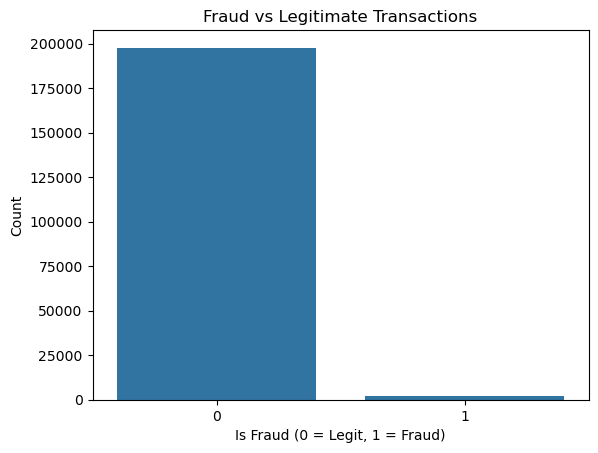

In [9]:
# Analyze the distribution of the target variable (is_fraud)
# This helps determine whether the dataset is balanced or imbalanced.

print(df['is_fraud'].value_counts())
print(df['is_fraud'].value_counts(normalize=True) * 100)

sns.countplot(x='is_fraud', data=df)
plt.title('Fraud vs Legitimate Transactions')
plt.xlabel('Is Fraud (0 = Legit, 1 = Fraud)')
plt.ylabel('Count')
plt.show()

- Legitimate transactions: 197,734 (98.87%)
- Fraudulent transactions: 2,266 (1.13%), indicating a highly imbalanced dataset.

### **Fraud Rate By Category**

                fraud_rate_%  transaction_count
category                                       
shopping_net            3.60              14788
misc_net                3.41               9285
grocery_pos             2.82              18789
shopping_pos            1.42              19717
gas_transport           0.90              17157
misc_pos                0.51              13234
food_dining             0.48              14905
travel                  0.42               6376
personal_care           0.41              14139
entertainment           0.41              14730
grocery_net             0.38               8487
health_fitness          0.33              12356
kids_pets               0.31              17239
home                    0.23              18798


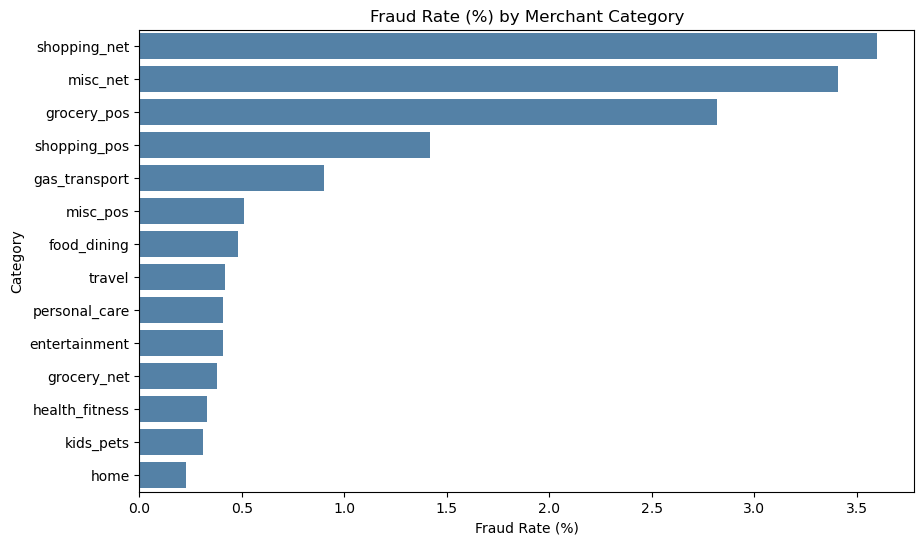

In [10]:
# Fraud rate by merchant category

category_fraud = df.groupby('category')['is_fraud'].agg(['mean', 'count']).sort_values('mean', ascending=False)
category_fraud['mean'] = (category_fraud['mean'] * 100).round(2)
category_fraud.columns = ['fraud_rate_%', 'transaction_count']
print(category_fraud)

plt.figure(figsize=(10,6))
sns.barplot(x=category_fraud['fraud_rate_%'], y=category_fraud.index, color='steelblue')
plt.title('Fraud Rate (%) by Merchant Category')
plt.xlabel('Fraud Rate (%)')
plt.ylabel('Category')
plt.show()

- Online merchant categories such as **shopping_net** (3.60%) and **misc_net** (3.41%) have the highest fraud rates.
- Categories like **gas_transport** (0.90%) and **home** (0.23%) show relatively lower fraud rates.

### **Fraud rate by transaction amount**

             count        mean         std  min      25%     50%       75%  \
is_fraud                                                                     
0         197734.0   68.409832  160.400288  1.0    9.070   44.38   81.4400   
1           2266.0  535.631368  391.400769  5.5  248.405  418.84  905.2925   

               max  
is_fraud            
0         20345.42  
1          1297.97  


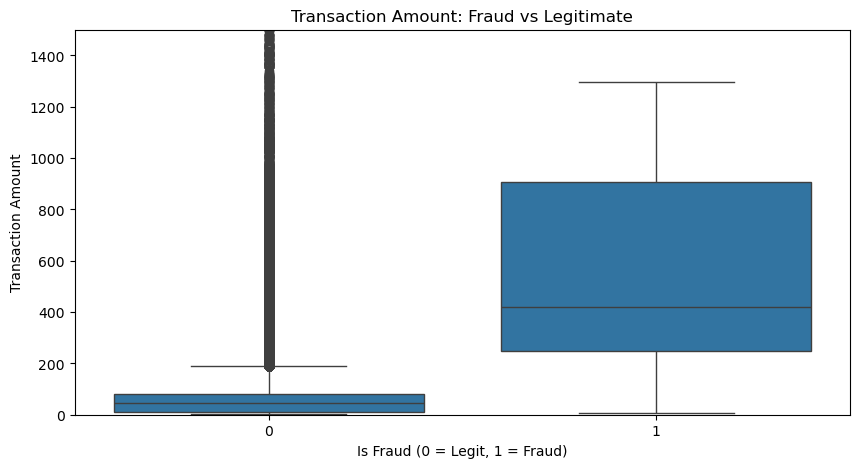

In [11]:
# Transaction amount distribution by class

print(df.groupby('is_fraud')['amt'].describe())

plt.figure(figsize=(10,5))
sns.boxplot(data=df, x='is_fraud', y='amt')

plt.title('Transaction Amount: Fraud vs Legitimate')
plt.xlabel('Is Fraud (0 = Legit, 1 = Fraud)')
plt.ylabel('Transaction Amount')
plt.ylim(0, 1500)  # zoom in, since a few extreme outliers would flatten the chart otherwise

plt.show()

- Fraudulent transactions have a much higher average transaction amount (\$535.63) than legitimate transactions (\$68.41).
- Fraud transactions are generally higher in value, indicating that **transaction amount (`amt`) is an important feature** for fraud detection.

### **Fraud rate by time of day**

            fraud_rate_%  transaction_count
trans_hour                                 
0                   3.08               6530
1                   3.00               6507
2                   3.27               6448
3                   3.28               6516
4                   0.22               6405
5                   0.21               6226
6                   0.22               6242
7                   0.34               6223
8                   0.20               6465
9                   0.22               6298
10                  0.27               6341
11                  0.19               6288
12                  0.20              10091
13                  0.25              10126
14                  0.22              10123
15                  0.22              10137
16                  0.20              10230
17                  0.24              10110
18                  0.16              10260
19                  0.25              10247
20                  0.24        

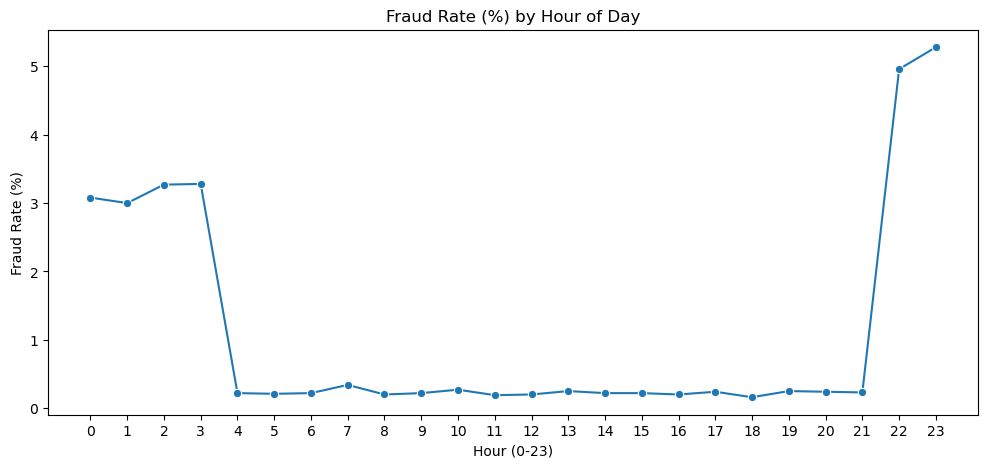

In [12]:
# Extract the hour from the transaction time
df['trans_hour'] = pd.to_datetime(df['trans_time'], format='%H:%M:%S').dt.hour

hourly_fraud = df.groupby('trans_hour')['is_fraud'].agg(['mean', 'count'])
hourly_fraud['mean'] = (hourly_fraud['mean'] * 100).round(2)
hourly_fraud.columns = ['fraud_rate_%', 'transaction_count']

print(hourly_fraud)

plt.figure(figsize=(12,5))
sns.lineplot(x=hourly_fraud.index, y=hourly_fraud['fraud_rate_%'], marker='o')

plt.title('Fraud Rate (%) by Hour of Day')
plt.xlabel('Hour (0-23)')
plt.ylabel('Fraud Rate (%)')
plt.xticks(range(0,24))
plt.show()

- Fraud rates are highest during late-night hours, peaking at **11 PM (5.28%)** and **10 PM (4.96%)**.
- Daytime hours have much lower fraud rates (around **0.2–0.3%**), suggesting that fraudulent transactions are more likely to occur at night.

### Correlation check

is_fraud      1.000000
amt           0.287339
trans_hour    0.009597
city_pop      0.004759
Name: is_fraud, dtype: float64


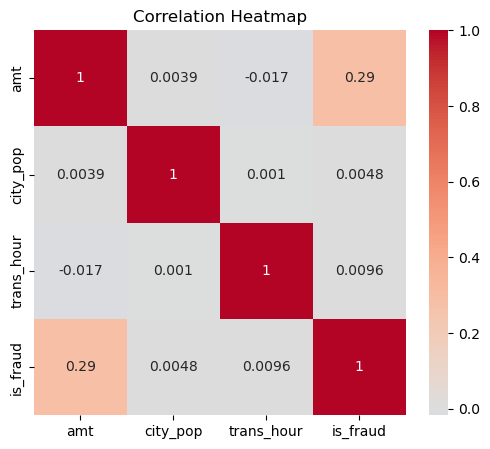

In [13]:
# Correlation of numeric features with fraud

numeric_cols = ['amt', 'city_pop', 'trans_hour', 'is_fraud']
corr = df[numeric_cols].corr()

print(corr['is_fraud'].sort_values(ascending=False))

plt.figure(figsize=(6,5))
sns.heatmap(corr, annot=True, cmap='coolwarm', center=0)
plt.title('Correlation Heatmap')

plt.show()

**Key Insights:**
- Transaction amount (`amt`) has the strongest positive correlation with fraud (0.287), making it a useful feature for fraud detection.
- `trans_hour` and `city_pop` show very weak linear correlations with fraud, suggesting they have limited direct linear relationships with the target variable.

### *Phase 5: Data Preprocessing*

In [14]:
# Drop identity/PII columns with no predictive value

drop_cols = ['ssn', 'first', 'last', 'street', 'acct_num', 'trans_num', 'profile', 'dob', 'gender', 'city', 'state', 'zip', 'job']
df = df.drop(columns=drop_cols)

print("Remaining columns:", list(df.columns))
print("New shape:", df.shape)

Remaining columns: ['cc_num', 'lat', 'long', 'city_pop', 'trans_date', 'trans_time', 'unix_time', 'category', 'amt', 'is_fraud', 'merchant', 'merch_lat', 'merch_long', 'trans_hour']
New shape: (200000, 14)


#### Finding: Dataset Reduced to Predictive Columns
- Removed 13 unnecessary columns, reducing the dataset from 27 to 14 columns. Only relevant transaction, location, and identifier fields were kept for preprocessing and feature engineering.This keeps only signal-relevant data going into preprocessing.

In [15]:
# Check duplicates + fix date/time types

print("Duplicate rows:", df.duplicated().sum())

df['trans_date'] = pd.to_datetime(df['trans_date'])
df['is_fraud'] = df['is_fraud'].astype(int)

print(df[['trans_date', 'is_fraud']].dtypes)

Duplicate rows: 0
trans_date    datetime64[ns]
is_fraud               int64
dtype: object


#### Finding: Data Clean and Ready

- No duplicate records were found. Date values were converted to the correct format, and the fraud column was verified as numeric. The dataset is now ready for feature engineering.


### *Phase 6: Feature Engineering*

#### **1. Distance between cardholder and merchant**

In [16]:
# Calculate distance between customer and merchant (in km), (Haversine formula)

def calculate_distance(lat1, lon1, lat2, lon2):
    R = 6371  # Earth radius (km)

    lat1, lon1, lat2, lon2 = map(np.radians, [lat1, lon1, lat2, lon2])

    a = (np.sin((lat2 - lat1) / 2) ** 2 +
         np.cos(lat1) * np.cos(lat2) *
         np.sin((lon2 - lon1) / 2) ** 2)

    return 2 * R * np.arcsin(np.sqrt(a))

# Create new column
df["distance_km"] = calculate_distance(
    df["lat"], df["long"],
    df["merch_lat"], df["merch_long"]
)

# Compare fraud vs non-fraud transactions
print(df.groupby("is_fraud")["distance_km"].describe()[["mean", "50%", "max"]])

               mean        50%         max
is_fraud                                  
0         76.278498  78.441536  148.620797
1         75.782026  77.872252  140.499316


#### Finding: Distance Has Little Impact

The average distance is similar for fraud and genuine transactions, so `distance_km` does not clearly separate the two. We'll test it as a candidate feature and remove it if it provides no meaningful improvement.

#### **2. Card-level transaction behavior**

In [17]:
# transaction count and average amount, trailing window

df = df.sort_values(['cc_num', 'unix_time']).reset_index(drop=True)

df['cumulative_txn_count'] = df.groupby('cc_num').cumcount()
df['avg_amt_prior_5'] = (
    df.groupby('cc_num')['amt']
    .transform(lambda x: x.shift(1).rolling(window=5, min_periods=1).mean())
)
df['amt_deviation'] = df['amt'] - df['avg_amt_prior_5']

print(df[['cc_num','cumulative_txn_count','amt','avg_amt_prior_5','amt_deviation','is_fraud']].head(10))
print("\nDeviation by class:")
print(df.groupby('is_fraud')['amt_deviation'].describe()[['mean','50%']])

        cc_num  cumulative_txn_count     amt  avg_amt_prior_5  amt_deviation  \
0  60400268763                     0    4.37              NaN            NaN   
1  60400268763                     1   20.63           4.3700        16.2600   
2  60400268763                     2  121.49          12.5000       108.9900   
3  60400268763                     3   82.28          48.8300        33.4500   
4  60400268763                     4  201.56          57.1925       144.3675   
5  60400268763                     5   53.26          86.0660       -32.8060   
6  60400268763                     6  131.85          95.8440        36.0060   
7  60400268763                     7    5.07         118.0880      -113.0180   
8  60400268763                     8   57.66          94.8040       -37.1440   
9  60400268763                     9   79.86          89.8800       -10.0200   

   is_fraud  
0         0  
1         0  
2         0  
3         0  
4         0  
5         0  
6         0  
7      

### Finding: Amount Deviation Is a Strong Fraud Signal

Legitimate transactions have a median deviation of **-13.10**, while fraud transactions have a median of **+281.75**. This shows that fraudulent transactions are much larger than the card's usual spending pattern.

This is more useful than looking at **`amt`** alone because it compares each transaction with the card's own spending behavior.

**Note:** The first transaction for each card has `NaN` because there is no previous transaction to compare with. This will need to be handled before modeling.

#### **3. Cyclical hour encoding**

In [18]:
# Cyclical encoding for trans_hour (closes the loop from Phase 4d)

df['hour_sin'] = np.sin(2 * np.pi * df['trans_hour'] / 24)
df['hour_cos'] = np.cos(2 * np.pi * df['trans_hour'] / 24)

print(df[['trans_hour', 'hour_sin', 'hour_cos']].drop_duplicates().sort_values('trans_hour'))

    trans_hour      hour_sin      hour_cos
52           0  0.000000e+00  1.000000e+00
12           1  2.588190e-01  9.659258e-01
1            2  5.000000e-01  8.660254e-01
18           3  7.071068e-01  7.071068e-01
22           4  8.660254e-01  5.000000e-01
9            5  9.659258e-01  2.588190e-01
7            6  1.000000e+00  6.123234e-17
10           7  9.659258e-01 -2.588190e-01
4            8  8.660254e-01 -5.000000e-01
19           9  7.071068e-01 -7.071068e-01
20          10  5.000000e-01 -8.660254e-01
0           11  2.588190e-01 -9.659258e-01
59          12  1.224647e-16 -1.000000e+00
58          13 -2.588190e-01 -9.659258e-01
61          14 -5.000000e-01 -8.660254e-01
63          15 -7.071068e-01 -7.071068e-01
80          16 -8.660254e-01 -5.000000e-01
31          17 -9.659258e-01 -2.588190e-01
68          18 -1.000000e+00 -1.836970e-16
60          19 -9.659258e-01  2.588190e-01
69          20 -8.660254e-01  5.000000e-01
64          21 -7.071068e-01  7.071068e-01
32         

### Finding: Cyclical Encoding Captures Time Patterns

We converted the hour into `sin` and `cos` values so that **23:00 and 00:00 are treated as close**, instead of being far apart like raw hour values.

This helps the model recognize continuous time patterns, such as the **22:00–03:00 high-risk period**, more effectively.

#### **Handle Missing Values**

In [19]:
# Fill NaNs created by rolling features (first transaction per card has no history)

print("NaNs before fill:\n", df[['avg_amt_prior_5','amt_deviation']].isnull().sum())

df['avg_amt_prior_5'] = df['avg_amt_prior_5'].fillna(df['amt'])
df['amt_deviation'] = df['amt_deviation'].fillna(0)

print("\nNaNs after fill:\n", df[['avg_amt_prior_5','amt_deviation']].isnull().sum())

NaNs before fill:
 avg_amt_prior_5    788
amt_deviation      788
dtype: int64

NaNs after fill:
 avg_amt_prior_5    0
amt_deviation      0
dtype: int64


### Finding: Missing Values Resolved

The **788 missing values** came from the first transaction of each card, where no previous history was available. They were filled using the current amount as the baseline and **0 for deviation**. The engineered features now have **no missing values**.

### *Phase 7: Time-Based Train/Test Split*

In [20]:
# Train / Validation / Test split — time-based, three-way
# Time-based split — train on earlier months, test on later months

train_cutoff = df['trans_date'].quantile(0.7)
val_cutoff = df['trans_date'].quantile(0.85)

train = df[df['trans_date'] <= train_cutoff]
val = df[(df['trans_date'] > train_cutoff) & (df['trans_date'] <= val_cutoff)]
test = df[df['trans_date'] > val_cutoff]

print("Train:", train.shape, "| fraud rate:", train['is_fraud'].mean())
print("Val:  ", val.shape, "| fraud rate:", val['is_fraud'].mean())
print("Test: ", test.shape, "| fraud rate:", test['is_fraud'].mean())

Train: (140123, 20) | fraud rate: 0.012603212891531011
Val:   (31059, 20) | fraud rate: 0.010850317138349592
Test:  (28818, 20) | fraud rate: 0.005656187105281422


### Finding: Three-Way Split Confirms the Seasonal Pattern

Fraud rate declines through the year: **1.26%** in train, **1.09%** in validation, and **0.57%** in test. The same pattern seen in the original split holds across three time windows, suggesting this is genuine seasonality rather than a split artifact.

#### **Select final features and encode category**

In [21]:
# Encode category across train/val/test consistently (distance_km removed — no predictive value per EDA)

feature_cols = ['amt', 'cumulative_txn_count', 'avg_amt_prior_5',
                 'amt_deviation', 'hour_sin', 'hour_cos', 'city_pop', 'category']

train_encoded = pd.get_dummies(train[feature_cols], columns=['category'], drop_first=True)
val_encoded = pd.get_dummies(val[feature_cols], columns=['category'], drop_first=True)
test_encoded = pd.get_dummies(test[feature_cols], columns=['category'], drop_first=True)

val_encoded = val_encoded.reindex(columns=train_encoded.columns, fill_value=0)
test_encoded = test_encoded.reindex(columns=train_encoded.columns, fill_value=0)

X_train, y_train = train_encoded, train['is_fraud']
X_val, y_val = val_encoded, val['is_fraud']
X_test, y_test = test_encoded, test['is_fraud']

print("X_train:", X_train.shape, "| X_val:", X_val.shape, "| X_test:", X_test.shape)

X_train: (140123, 20) | X_val: (31059, 20) | X_test: (28818, 20)


### Finding: Feature Set Finalized

The final feature set contains **20 features**, with the same columns across train, validation, and test sets.

This ensures the model receives **consistent inputs across all three splits**.

### *Phase 8: Model Building*

In [22]:
# Logistic Regression baseline (train + predict, same pattern as XGBoost cell)

from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import average_precision_score

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

baseline = LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)
baseline.fit(X_train_scaled, y_train)

baseline_test_probs = baseline.predict_proba(X_test_scaled)[:, 1]

print("Baseline trained.")
print("Baseline test PR-AUC:", average_precision_score(y_test, baseline_test_probs))

Baseline trained.
Baseline test PR-AUC: 0.00412372109923819


In [23]:
# Train XGBoost with early stopping (uses validation set to prevent overfitting)

from xgboost import XGBClassifier
from sklearn.metrics import average_precision_score

model = XGBClassifier(
    n_estimators=500,
    max_depth=5,
    learning_rate=0.1,
    scale_pos_weight=(y_train == 0).sum() / (y_train == 1).sum(),
    eval_metric='aucpr',
    early_stopping_rounds=20,
    random_state=42
)

model.fit(X_train, y_train, eval_set=[(X_val, y_val)], verbose=False)

xgb_train_probs = model.predict_proba(X_train)[:, 1]
xgb_val_probs = model.predict_proba(X_val)[:, 1]
xgb_test_probs = model.predict_proba(X_test)[:, 1]

print("Best iteration:", model.best_iteration)
print(f"Train PR-AUC: {average_precision_score(y_train, xgb_train_probs):.4f}")
print(f"Val PR-AUC:   {average_precision_score(y_val, xgb_val_probs):.4f}")
print(f"Test PR-AUC:  {average_precision_score(y_test, xgb_test_probs):.4f}")

Best iteration: 37
Train PR-AUC: 0.8092
Val PR-AUC:   0.7389
Test PR-AUC:  0.6332


### Finding: Model Performance After Feature Selection

- Early stopping fixed the overfitting problem
- Dropping `distance_km` had no meaningful impact

| Metric | With `distance_km` | Without `distance_km` |
|---|---:|---:|
| Train PR-AUC | 0.7879 | 0.8092 |
| Val PR-AUC | 0.7224 | 0.7389 |
| Test PR-AUC | 0.6240 | 0.6332 |

Early stopping halted training at iteration 37 based on validation performance. The smaller train-test gap indicates better generalization without significant overfitting.

### *Phase 9: Model Evaluation*

In [24]:
# PR-AUC and ROC-AUC comparison — XGBoost vs baseline, on held-out test set

from sklearn.metrics import roc_auc_score

xgb_test_pr_auc = average_precision_score(y_test, xgb_test_probs)
xgb_test_roc_auc = roc_auc_score(y_test, xgb_test_probs)

baseline_pr_auc = average_precision_score(y_test, baseline_test_probs)
baseline_roc_auc = roc_auc_score(y_test, baseline_test_probs)

no_skill_baseline = y_test.mean()  # PR-AUC's reference line = positive class rate

print(f"XGBoost     — PR-AUC: {xgb_test_pr_auc:.4f} | ROC-AUC: {xgb_test_roc_auc:.4f}")
print(f"Baseline LR — PR-AUC: {baseline_pr_auc:.4f} | ROC-AUC: {baseline_roc_auc:.4f}")
print(f"No-skill PR-AUC (= test fraud rate): {no_skill_baseline:.4f}")

XGBoost     — PR-AUC: 0.6332 | ROC-AUC: 0.9701
Baseline LR — PR-AUC: 0.0041 | ROC-AUC: 0.0964
No-skill PR-AUC (= test fraud rate): 0.0057


### Finding: XGBoost Strongly Outperforms Baselines
| Model | PR-AUC | ROC-AUC |
|---|---|---|
| XGBoost | 0.6332 | 0.9701 |
| Logistic Regression | 0.0041 | 0.0964 |
| No-skill baseline | 0.0057 | 0.50 |

XGBoost's PR-AUC (0.63) is over 100× the no-skill baseline, showing strong predictive signal on the untouched test set. Logistic Regression performs below the no-skill baseline on both metrics, suggesting the data has non-linear patterns that XGBoost captures better.

### *Phase 10: Business Impact / Threshold Optimization*

In [25]:
# Define cost assumptions from train set only

avg_fraud_loss = train[train['is_fraud'] == 1]['amt'].mean()
avg_false_decline_cost = train['amt'].mean() * 0.13

print(f"Avg fraud loss per missed case (FN): ${avg_fraud_loss:.2f}")
print(f"Avg false decline cost per case (FP): ${avg_false_decline_cost:.2f}")

Avg fraud loss per missed case (FN): $538.53
Avg false decline cost per case (FP): $9.99


### Finding: Cost Assumptions Now Train-Only

Fraud loss (**\$538.53**) and false decline cost (**\$9.99**) remain close to the earlier full-dataset values (**\$535.63**, **\$9.58**). More importantly, the costs are now estimated from **training data only**, avoiding test-period leakage.

#### **Sweep thresholds, find the cost-minimizing point**

In [26]:
# Find cost-optimal threshold using validation set

thresholds = np.arange(0.01, 0.99, 0.01)
val_results = []

for t in thresholds:
    preds = (xgb_val_probs >= t).astype(int)
    fp = ((preds == 1) & (y_val == 0)).sum()
    fn = ((preds == 0) & (y_val == 1)).sum()
    total_cost = fp * avg_false_decline_cost + fn * avg_fraud_loss
    val_results.append({'threshold': t, 'total_cost': total_cost})

val_cost_df = pd.DataFrame(val_results)
optimal_threshold = val_cost_df.loc[val_cost_df['total_cost'].idxmin(), 'threshold']

print(f"Optimal threshold: {optimal_threshold:.2f}")

Optimal threshold: 0.52


In [27]:
# Apply Threshold - Final cost evaluation on held-out test set

def calculate_cost(probs, actuals, threshold):
    preds = (probs >= threshold).astype(int)
    fp = ((preds == 1) & (actuals == 0)).sum()
    fn = ((preds == 0) & (actuals == 1)).sum()
    return fp * avg_false_decline_cost + fn * avg_fraud_loss

optimal_cost = calculate_cost(xgb_test_probs, y_test, optimal_threshold)
default_cost = calculate_cost(xgb_test_probs, y_test, 0.5)

print(f"Cost at optimal threshold ({optimal_threshold:.2f}): ${optimal_cost:,.2f}")
print(f"Cost at default threshold (0.50): ${default_cost:,.2f}")
print(f"Savings: ${default_cost - optimal_cost:,.2f} "
      f"({(default_cost - optimal_cost) / default_cost * 100:.1f}%)")

Cost at optimal threshold (0.52): $29,264.55
Cost at default threshold (0.50): $30,824.61
Savings: $1,560.06 (5.1%)


### Finding: Validation-Based Threshold Gives Credible Results
Optimal threshold (validation): **0.52**.
- Cost at optimal threshold: \$29,264.55
- Cost at default threshold (0.5): \$30,824.61
- **Savings: $1,560.06 (5.1\%)**

The threshold was selected on the validation set and applied once to the untouched test set, avoiding leakage. Since the optimal threshold (0.52) sits close to the default (0.5), there's limited room between them, resulting in a modest but reliable cost improvement.

In [28]:
# Fraud catch rate and false decline count at the optimal threshold (test set)

test_preds = (xgb_test_probs >= optimal_threshold).astype(int)
fraud_caught = ((test_preds == 1) & (y_test == 1)).sum()
fraud_missed = ((test_preds == 0) & (y_test == 1)).sum()
false_declines = ((test_preds == 1) & (y_test == 0)).sum()
total_fraud = y_test.sum()

print(f"Total fraud cases in test set: {total_fraud}")
print(f"Fraud caught at threshold {optimal_threshold:.2f}: {fraud_caught} ({fraud_caught/total_fraud*100:.1f}%)")
print(f"Fraud missed: {fraud_missed}")
print(f"False declines: {false_declines}")

Total fraud cases in test set: 163
Fraud caught at threshold 0.52: 142 (87.1%)
Fraud missed: 21
False declines: 1798


### Finding: Strong Fraud Coverage at the Validation-Selected Threshold
At threshold 0.52, the model catches 87.1% of fraud (142/163 cases), with 21 missed fraud cases and 1,798 false declines.

**Final headline:** at a validation-selected, cost-optimized threshold, the model catches 87% of fraud on unseen test data while reducing total business cost by 5.1% versus the default 0.5 threshold.

In [32]:
# Confusion matrix and classification report at the final threshold (test set)

from sklearn.metrics import confusion_matrix, classification_report

test_preds = (xgb_test_probs >= optimal_threshold).astype(int)

print("Confusion Matrix:")
print(confusion_matrix(y_test, test_preds))
print("\nClassification Report:")
print(classification_report(y_test, test_preds, target_names=['Legitimate', 'Fraud']))

Confusion Matrix:
[[26857  1798]
 [   21   142]]

Classification Report:
              precision    recall  f1-score   support

  Legitimate       1.00      0.94      0.97     28655
       Fraud       0.07      0.87      0.14       163

    accuracy                           0.94     28818
   macro avg       0.54      0.90      0.55     28818
weighted avg       0.99      0.94      0.96     28818



### Finding: Confusion Matrix Confirms the Cost Tradeoff
| | Predicted Legit | Predicted Fraud |
|---|---|---|
| **Actual Legit** | 26,857 | 1,798 |
| **Actual Fraud** | 21 | 142 |

Fraud recall is 87\%, but precision is only 7\% — most flagged transactions are legitimate. Intentional: a missed fraud case costs ~54x more than a false decline, so the threshold favors catching fraud over avoiding false declines. Accuracy (94\%) isn't meaningful here given the imbalance.

In [29]:
# Save the trained XGBoost model and the feature column list

model.save_model('fraud_model.json')

import json
with open('feature_columns.json', 'w') as f:
    json.dump(list(X_train.columns), f)

print("Model and feature columns saved.")

Model and feature columns saved.


In [30]:
# Build feature store using the same logic as training

df_sorted = df.sort_values(['cc_num', 'unix_time']).reset_index(drop=True)

df_sorted['avg_amt_prior_5'] = (
    df_sorted.groupby('cc_num')['amt']
    .transform(lambda x: x.shift(1).rolling(window=5, min_periods=1).mean())
)
df_sorted['cumulative_txn_count'] = df_sorted.groupby('cc_num').cumcount()

# Keep each card's most recent known state — mirrors what a live feature store would serve
feature_store = (
    df_sorted.groupby('cc_num')
    .last()[['avg_amt_prior_5', 'cumulative_txn_count']]
    .reset_index()
)

sample_cards = feature_store.sample(20, random_state=42)
sample_cards.to_json('feature_store.json', orient='records')

print(sample_cards.head())
print(f"\n{len(sample_cards)} cards saved to feature_store.json")

               cc_num  avg_amt_prior_5  cumulative_txn_count
571  4476818268323039          298.754                   560
39       630474584764           57.818                   323
211   180084219933088           27.648                   505
199   180030120471379          572.110                     2
235   213151985458292           93.106                   288

20 cards saved to feature_store.json


### Finding: Feature Store Now Matches Training Logic

Card `4476818268323039`'s `avg_amt_prior_5` changed from **60.70** to **298.75**, reflecting the correct last-5-transactions average rather than the old full-year mean.

**Impact:** The app's known-card test will now produce a different fraud probability, as it is using the same feature definition as training.

In [31]:
# app.py — Three-tier decision logic

app_code = '''
import streamlit as st
import pandas as pd
import numpy as np
import json
from xgboost import XGBClassifier

CATEGORIES = [
    "food_dining", "gas_transport", "grocery_net", "grocery_pos", "health_fitness",
    "home", "kids_pets", "misc_net", "misc_pos", "personal_care",
    "shopping_net", "shopping_pos", "travel"
]
DECLINE_THRESHOLD = 0.52
REVIEW_THRESHOLD = 0.30

@st.cache_resource
def load_artifacts():
    model = XGBClassifier()
    model.load_model("fraud_model.json")
    with open("feature_columns.json") as f:
        feature_columns = json.load(f)
    with open("feature_store.json") as f:
        feature_store = pd.DataFrame(json.load(f))
    return model, feature_columns, feature_store

model, feature_columns, feature_store = load_artifacts()

st.title("Fraud Detection - Transaction Risk Scorer")
st.write("Simulates a real-time authorization decision for a card payment network.")

cc_num = st.text_input("Card Number (try a known ID, or any number for a new card)")
amt = st.number_input("Transaction Amount ($)", min_value=0.0, value=50.0)
category = st.selectbox("Merchant Category", CATEGORIES)
hour = st.slider("Transaction Hour (0-23)", 0, 23, 12)
city_pop = st.number_input("Cardholder City Population", min_value=0, value=50000)

if st.button("Score Transaction"):
    card_row = feature_store[feature_store["cc_num"].astype(str) == cc_num]
    if len(card_row) > 0:
        avg_amt_prior_5 = card_row["avg_amt_prior_5"].values[0]
        cumulative_txn_count = card_row["cumulative_txn_count"].values[0]
        st.info("Known card - using stored transaction history.")
    else:
        avg_amt_prior_5 = amt
        cumulative_txn_count = 0
        st.info("New card - no history found, using cold-start defaults.")

    row = {col: 0 for col in feature_columns}
    row["amt"] = amt
    row["cumulative_txn_count"] = cumulative_txn_count
    row["avg_amt_prior_5"] = avg_amt_prior_5
    row["amt_deviation"] = amt - avg_amt_prior_5
    row["hour_sin"] = np.sin(2 * np.pi * hour / 24)
    row["hour_cos"] = np.cos(2 * np.pi * hour / 24)
    row["city_pop"] = city_pop
    cat_col = f"category_{category}"
    if cat_col in row:
        row[cat_col] = 1

    X = pd.DataFrame([row])[feature_columns]
    prob = model.predict_proba(X)[0][1]

    st.metric("Fraud Probability", f"{prob:.2%}")

    if prob >= DECLINE_THRESHOLD:
        st.error(f"DECLINE - probability ({prob:.2%}) exceeds the cost-optimized threshold ({DECLINE_THRESHOLD:.0%})")
    elif prob >= REVIEW_THRESHOLD:
        st.warning(f"REVIEW - probability ({prob:.2%}) is elevated; route for step-up verification")
    else:
        st.success(f"APPROVE - probability ({prob:.2%}) is low risk")

    st.caption(f"Deviation from card's typical spend: ${row['amt_deviation']:.2f}")
'''

with open('app.py', 'w', encoding='utf-8') as f:
    f.write(app_code)

print("app.py with three-tier decision logic.")

app.py with three-tier decision logic.


### Finding: Three-Tier Decision Logic Verified
All three decision tiers confirmed working correctly with the final model (threshold 0.52, `distance_km` removed, corrected feature store):
- **APPROVE** (2.81\%) — \$50 grocery purchase on a known card, in line with normal spending.
- **REVIEW** (50.00\%) — \$250 grocery purchase on the same card, notably above its typical spend — elevated but not extreme, correctly routed for step-up verification instead of a hard decline.
- **DECLINE** (98.86\%) — high-risk category, high-risk hour, and elevated amount stacked together on a new card, correctly flagged.

The model responds proportionally to genuine risk signals, and the three-tier design avoids a binary approve/decline split — a moderately unusual transaction like the \$250 case is neither clearly safe nor clearly fraudulent, and is now routed accordingly.

In [33]:
requirements = """streamlit
pandas
numpy
xgboost
scikit-learn
"""

with open('requirements.txt', 'w') as f:
    f.write(requirements)

print("requirements.txt created.")

requirements.txt created.
